In [1]:
import sklearn
import numpy as np
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [2]:
def augment_data_Z2(data, shuffle=True, seed=0):
    # data: shape (num_samples, L)
    num_samples, L = data.shape
    augmented_data = np.zeros((num_samples*2, L))
    augmented_data[:num_samples, :] = data
    augmented_data[num_samples:, :] = - data  # Flip spins
    
    if shuffle:
        np.random.seed(seed)
        np.random.shuffle(augmented_data)
    
    return augmented_data

In [8]:
x = np.array([[1, 2, 3], [4,5,6]])
np.random.shuffle(x)
x

array([[1, 2, 3],
       [4, 5, 6]])

In [5]:
sys_data = np.load("data/CritIsing_L20_beta0.3_Zoutcomes_sys.npy")
anc_data = np.load("data/CritIsing_L20_beta0.3_Zoutcomes_anc.npy")

In [28]:
N = 100000
seed = 0
np.random.seed(seed)
indices = np.random.permutation(len(sys_data))
X_train = anc_data[indices[:N]]
y_train = sys_data[indices[:N], 0]

In [32]:
my_model = XGBRegressor(n_estimators=100, seed=42)
my_model.fit(X_train, y_train)
MSE_train = mean_squared_error(y_train, my_model.predict(X_train))

In [33]:
1 - MSE_train

0.5570089519023895

8 0.49740755558013916
10 0.5088864862918854
12 0.5193032920360565
14 0.5269168615341187
16 0.5318341851234436
18 0.5350159704685211
20 0.5371703207492828
40 0.5485050678253174


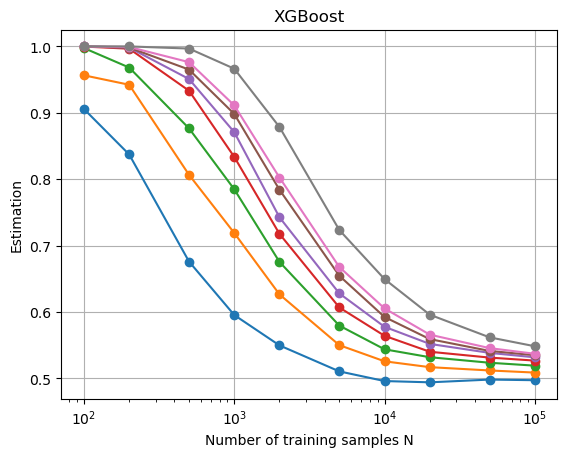

In [54]:
n_estimators = 20
xgb_seed = 42
N_list = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]
for L in [8, 10, 12, 14, 16, 18, 20, 40]:
    sys_data = np.load(f"data/CritIsing_L{L}_beta0.3_Zoutcomes_sys.npy")
    anc_data = np.load(f"data/CritIsing_L{L}_beta0.3_Zoutcomes_anc.npy")

    A_list = []
    for N in N_list:
        X_train = anc_data[indices[:N]]
        y_train = sys_data[indices[:N], 0]
        
        my_model = XGBRegressor(n_estimators=n_estimators, seed=xgb_seed)
        my_model.fit(X_train, y_train)
        MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
        A_list.append(1 - MSE_train)

    plt.plot(N_list, A_list, marker='o', label=f'L={L}')
    print(L, A_list[-1])
plt.xscale('log')
plt.xlabel('Number of training samples N')
plt.ylabel('Estimation')
plt.title('XGBoost')
plt.grid(True)

Extrapolated value at N->infinity: 0.8776537004979084


Text(0.5, 0, '$N^{-1.00}$')

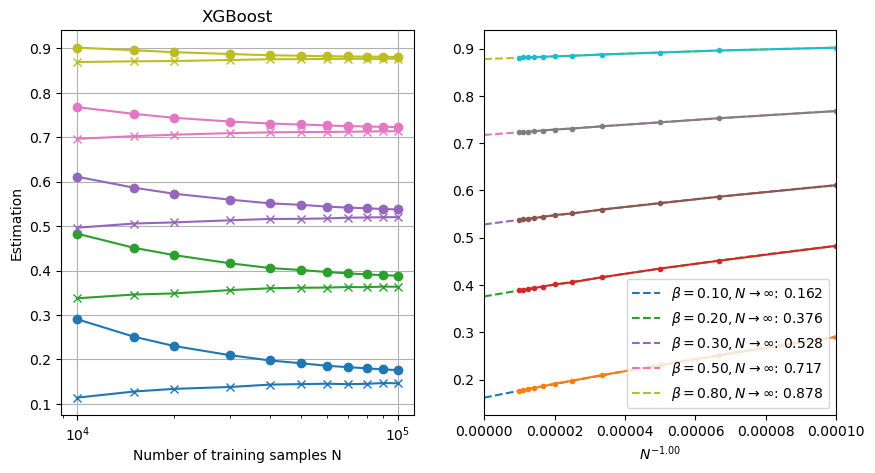

In [31]:

fig, axes = plt.subplots(1,2,figsize=(10,5))

n_estimators = 20
xgb_seed = 42
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
L = 20
beta_list = [0.1, 0.2, 0.3, 0.5, 0.8]
Estimated_value_list = []
for beta in beta_list:
    seed = 2
    np.random.seed(seed)
    sys_data = np.load(f"temp/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_sys.npy")
    anc_data = np.load(f"temp/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_anc.npy")
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i]
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i]
            
            my_model = XGBRegressor(n_estimators=n_estimators, seed=xgb_seed, max_depth=6)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('XGBoost')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

print("Extrapolated value at N->infinity:", poly(0))
ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

Extrapolated value at N->infinity: 0.8785431652315622


Text(0.5, 0, '$N^{-1.00}$')

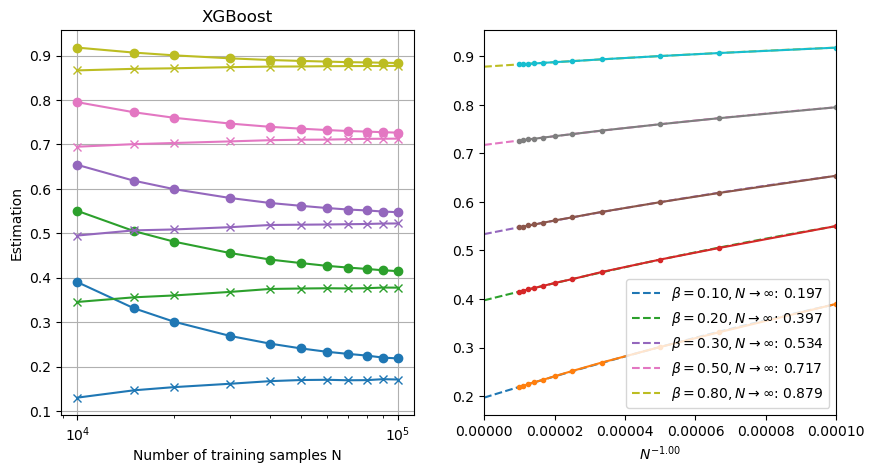

In [45]:

fig, axes = plt.subplots(1,2,figsize=(10,5))

n_estimators = 20
xgb_seed = 42
N_list = [10000, 15000, 20000,30000, 40000, 50000, 60000, 70000, 80000, 90000,100000]
L = 40
beta_list = [0.1, 0.2, 0.3, 0.5, 0.8]
Estimated_value_list = []
for beta in beta_list:
    seed = 2
    np.random.seed(seed)
    sys_data = np.load(f"temp/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_sys.npy")
    anc_data = np.load(f"temp/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_anc.npy")
    sys_data = augment_data_Z2(sys_data, shuffle=True, seed=seed)
    anc_data = augment_data_Z2(anc_data, shuffle=True, seed=seed)
    
    indices = np.random.permutation(len(sys_data))

    A_list_train = []
    A_list_test = []
    for N in N_list:
        MSE_train_list = []
        MSE_test_list = []
        for i in range(L):
            X_train = anc_data[indices[:N]]
            y_train = sys_data[indices[:N], i]
            
            X_test = anc_data[indices[N:2*N]]
            y_test = sys_data[indices[N:2*N], i]
            
            my_model = XGBRegressor(n_estimators=n_estimators, seed=xgb_seed, max_depth=6)
            my_model.fit(X_train, y_train)
            MSE_train = mean_squared_error(y_train, my_model.predict(X_train))
            MSE_train_list.append(MSE_train)
            MSE_test = mean_squared_error(y_test, my_model.predict(X_test))
            MSE_test_list.append(MSE_test)
        A_list_train.append(1-np.mean(MSE_train_list))
        A_list_test.append(1-np.mean(MSE_test_list))
    ax = axes[0]
    ax.plot(N_list, A_list_train, marker='o', label=f'L={L}')
    ax.plot(N_list, A_list_test, marker='x', label=f'L={L} (test)')
    ax.get_lines()[-1].set_color(ax.get_lines()[-2].get_color())


    ax = axes[1]
    y = np.array(A_list_train)
    x = np.array(N_list)
    powerlaw_exponent = 1.0
    x_ = 1/np.power(x,powerlaw_exponent)
    coefficients = np.polyfit(x_, y, 2)
    poly = np.poly1d(coefficients)
    x_fit = np.linspace(0, max(x_), 100)
    y_fit = poly(x_fit)
    ax.plot(x_fit, y_fit, '--', label=r'$\beta = %.2f, N\to\infty$: %.3f' % (beta, poly(0)))
    ax.plot(x_, y, '.-')
    Estimated_value_list.append(poly(0))

ax = axes[0]
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Number of training samples N')
ax.set_ylabel('Estimation')
ax.set_title('XGBoost')
ax.grid(True)

ax = axes[1]
ax.set_xlim(0, max(x_))
ax.legend()

print("Extrapolated value at N->infinity:", poly(0))
ax.set_xlabel(r'$N^{%.2f}$' % (-powerlaw_exponent))

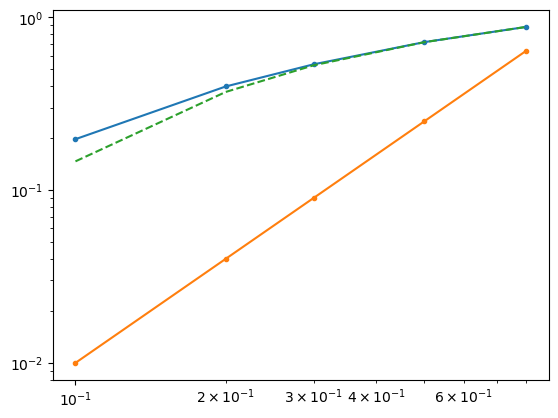

In [46]:
plt.plot(beta_list, Estimated_value_list, '.-', label="Estimated")
x = np.array(beta_list)
y = np.array(Estimated_value_list)
plt.xscale('log')
plt.yscale('log')
plt.plot(x, np.power(x, 2), '.-')

y_theory = []
for beta in beta_list:
    y_theory.append(np.load(f'temp/CritIsing_L16_beta{beta}_Zsecond_moment_theory.npy'))

y_theory = np.array(y_theory)
plt.xscale('log')
plt.yscale('log')
plt.plot(x, y_theory, '--', label="Theory")

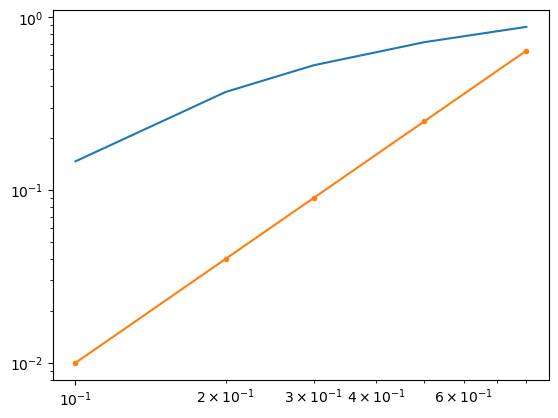

In [40]:

fig = plt.plot(figsize=(8, 5))
ax = plt.gca()
L = 16
# beta_list = [0.001, 0.002, 0.005, 0.01,0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
beta_list = [0.1, 0.2, 0.3, 0.5, 0.8]
results = []
y = []
for beta in beta_list:
    y.append(np.load(f'temp/CritIsing_L{L}_beta{beta}_Zsecond_moment_theory.npy'))

x = np.array(beta_list)
y = np.array(y)
plt.xscale('log')
plt.yscale('log')
plt.plot(x, y)
plt.plot(x, np.power(x, 2), '.-')


In [36]:
y

array([0.93709208])